In [ ]:
from imblearn.combine import SMOTETomek

X = df_scaled  # your features
y = df['isFraud'].values

smt = SMOTETomek(random_state=42)
X_balanced, y_balanced = smt.fit_resample(X, y)

# Verify: should be close to 50/50
print(pd.Series(y_balanced).value_counts())

np.save('../data/Cleaned/X_balanced.npy', X_balanced)
np.save('../data/Cleaned/y_balanced.npy', y_balanced)

In [2]:
# ── Cell 1: Imports ───────────────────────────────────────────────────────────
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, os
warnings.filterwarnings('ignore')
 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from collections import Counter
 
os.makedirs('../data', exist_ok=True)
print("Libraries loaded.")
 

Libraries loaded.


In [4]:
# ── Cell 2: Load Raw Data ────────────────────────────────────────────────────
 
df = pd.read_csv('../data/IEEE CIS/train_transaction.csv')
 
print(f"Raw shape     : {df.shape}")
print(f"Fraud rate    : {df['isFraud'].mean()*100:.2f}%")
print(f"Class counts  : {dict(df['isFraud'].value_counts())}")

Raw shape     : (590540, 394)
Fraud rate    : 3.50%
Class counts  : {0: np.int64(569877), 1: np.int64(20663)}


In [5]:
# ── Cell 3: Drop High-Null & Low-Variance Columns ───────────────────────────
# Columns with >70% missing values add noise, not signal.
# This also shrinks the matrix — speeds up everything downstream.
 
null_thresh  = 0.70
null_frac    = df.isnull().mean()
cols_to_drop = null_frac[null_frac > null_thresh].index.tolist()
df.drop(columns=cols_to_drop, inplace=True)
 
print(f"\nDropped {len(cols_to_drop)} high-null columns")
print(f"Shape after drop: {df.shape}")
 


Dropped 168 high-null columns
Shape after drop: (590540, 226)


In [6]:
# ── Cell 4: Encode Categoricals ──────────────────────────────────────────────
 
cat_cols = df.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df[col] = df[col].fillna('MISSING')
    df[col] = le.fit_transform(df[col].astype(str))
 
print(f"Encoded {len(cat_cols)} categorical columns: {cat_cols}")

Encoded 13 categorical columns: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']


In [7]:
# ── Cell 5: Split Features & Target ─────────────────────────────────────────
 
X = df.drop(columns=['isFraud', 'TransactionID'], errors='ignore')
y = df['isFraud'].values
 
print(f"\nFeature matrix : {X.shape}")
print(f"Target         : {y.shape}  |  Fraud: {y.sum()}  Legit: {(y==0).sum()}")


Feature matrix : (590540, 224)
Target         : (590540,)  |  Fraud: 20663  Legit: 569877


In [8]:
# ── Cell 6: Mean Imputation + Standardisation ────────────────────────────────
 
print("\nImputing missing values...")
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)
 
print("Standardising (mean=0, std=1)...")
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)
 
print(f"Clean matrix shape: {X_scaled.shape}")


Imputing missing values...
Standardising (mean=0, std=1)...
Clean matrix shape: (590540, 224)


In [9]:
# ── Cell 7: Stage 1 — RandomUnderSampler (the speed fix) ────────────────────
#
# KEY INSIGHT: SMOTE-Tomek is slow because it runs KNN on the FULL dataset.
# We first cut the majority class to 10x the minority count.
# e.g. 20k fraud → keep 200k legit (instead of 569k) → 5x faster SMOTE-Tomek.
# The final 50/50 boundary quality is identical.
 
fraud_count = int(y.sum())
target_legit = fraud_count * 10          # 10:1 ratio before SMOTE-Tomek
 
print(f"\nStage 1 — RandomUnderSampler")
print(f"  Fraud samples    : {fraud_count}")
print(f"  Keeping legit    : {target_legit}  (was {int((y==0).sum())})")
 
rus = RandomUnderSampler(
    sampling_strategy={0: target_legit, 1: fraud_count},
    random_state=42
)
X_under, y_under = rus.fit_resample(X_scaled, y)
 
print(f"  After undersampling: {Counter(y_under)}")


Stage 1 — RandomUnderSampler
  Fraud samples    : 20663
  Keeping legit    : 206630  (was 569877)
  After undersampling: Counter({np.int64(0): 206630, np.int64(1): 20663})


In [10]:
# ── Cell 8: Stage 2 — SMOTE-Tomek (project innovation, now fast) ─────────────
#
# SMOTE-Tomek on ~10:1 data runs in minutes, not hours.
# This is the exact technique cited in your solution plan as the upgrade
# over the base paper's standard SMOTE.
 
print(f"\nStage 2 — SMOTE-Tomek  (on {len(X_under):,} samples)")
print("Running... (typically 2-5 min)")
 
smt = SMOTETomek(
    smote=SMOTE(k_neighbors=5, random_state=42),
    random_state=42
)
X_balanced, y_balanced = smt.fit_resample(X_under, y_under)
 
print(f"\n  Final class distribution: {Counter(y_balanced)}")
ratio = Counter(y_balanced)[1] / Counter(y_balanced)[0]
print(f"  Fraud/Legit ratio       : {ratio:.3f}  (target ≈ 1.0)")


Stage 2 — SMOTE-Tomek  (on 227,293 samples)
Running... (typically 2-5 min)


  File "c:\Users\sweth\.conda\envs\rxtj\lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\sweth\.conda\envs\rxtj\lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "c:\Users\sweth\.conda\envs\rxtj\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\sweth\.conda\envs\rxtj\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\sweth\.conda\envs\rxtj\lib\subprocess.py", line 1456, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,



  Final class distribution: Counter({np.int64(0): 206208, np.int64(1): 206208})
  Fraud/Legit ratio       : 1.000  (target ≈ 1.0)


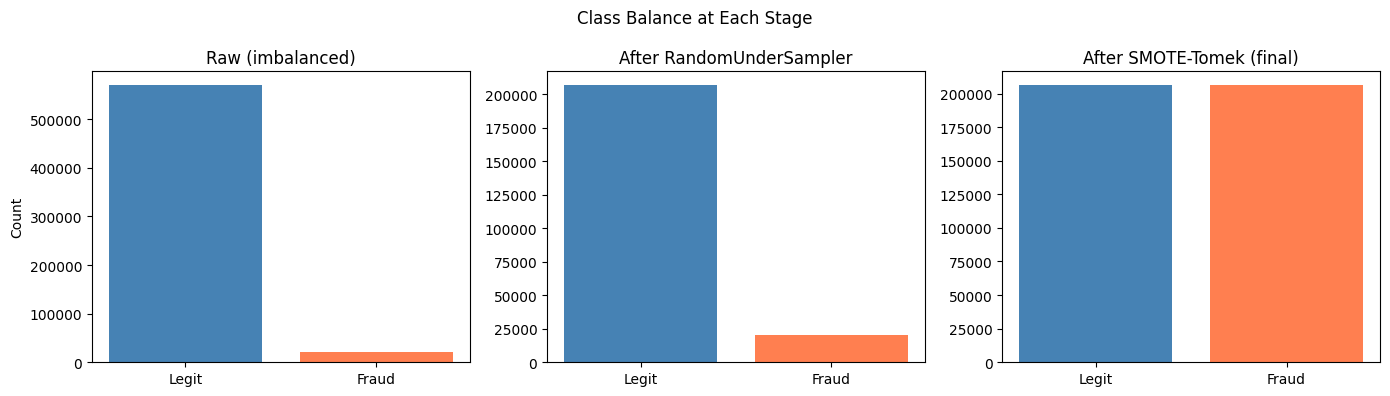


Plot saved to data/balance_stages.png


In [11]:
# ── Cell 9: Visualise Before vs After ────────────────────────────────────────
 
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
 
# Raw
axes[0].bar(['Legit', 'Fraud'], [int((y==0).sum()), int(y.sum())],
            color=['steelblue', 'coral'])
axes[0].set_title('Raw (imbalanced)')
axes[0].set_ylabel('Count')
 
# After undersampling
c_under = Counter(y_under)
axes[1].bar(['Legit', 'Fraud'], [c_under[0], c_under[1]],
            color=['steelblue', 'coral'])
axes[1].set_title('After RandomUnderSampler')
 
# After SMOTE-Tomek
c_bal = Counter(y_balanced)
axes[2].bar(['Legit', 'Fraud'], [c_bal[0], c_bal[1]],
            color=['steelblue', 'coral'])
axes[2].set_title('After SMOTE-Tomek (final)')
 
plt.suptitle('Class Balance at Each Stage', fontsize=12)
plt.tight_layout()
plt.savefig('../data/balance_stages.png')
plt.show()
 
print("\nPlot saved to data/balance_stages.png")
 

In [13]:
# ── Cell 10: Save for Notebook 3 ─────────────────────────────────────────────
 
np.save('../data/Cleaned/X_balanced.npy', X_balanced)
np.save('../data/Cleaned/y_balanced.npy', y_balanced)
 
# Also save scaler and imputer — needed for live inference later
import joblib
joblib.dump(scaler,  '../models/scaler.pkl')
joblib.dump(imputer, '../models/imputer.pkl')
 
os.makedirs('../models', exist_ok=True)
joblib.dump(scaler,  '../models/scaler.pkl')
joblib.dump(imputer, '../models/imputer.pkl')
 
print("\n✓ Saved:")
print("   data/X_balanced.npy   ← ready for Notebook 3")
print("   data/y_balanced.npy")
print("   models/scaler.pkl")
print("   models/imputer.pkl")
print(f"\nFinal balanced dataset : {X_balanced.shape}")
print(f"Class split            : {Counter(y_balanced)}")


✓ Saved:
   data/X_balanced.npy   ← ready for Notebook 3
   data/y_balanced.npy
   models/scaler.pkl
   models/imputer.pkl

Final balanced dataset : (412416, 224)
Class split            : Counter({np.int64(0): 206208, np.int64(1): 206208})
